In [1]:
import numpy as np
import json
import pandas as pd
import itertools
import glob

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

from scipy.integrate import simpson, romb
from scipy.interpolate import interp1d
from scipy.stats import binom
from scipy.ndimage import gaussian_filter

from default_globals import *
from redshift_utils import *
from utils import *

CATALOG_PATH = "/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv"
quaia = pd.read_csv(CATALOG_PATH)
mean_err_quaia = np.median( quaia["redshift_quaia_err"] )  # .loc[quaia['loglbol_corr'] >= 46.5]
print(mean_err_quaia, np.median( quaia["redshift_quaia_err"].loc[quaia['loglbol_corr'] >= 46.5] ))
from utils import make_nice_plots
make_nice_plots()

0.10620452251911165 0.1062159228324889


In [2]:
def get_cdfs(posteriors, integral_axis=LOG_LLH_X_AX):
    pdfs = get_pdfs(posteriors, integral_axis)
    cdfs = np.cumsum(pdfs, axis=0) * np.diff(LOG_LLH_X_AX)[0]
    cdfs /= cdfs[-1, :]
    return cdfs


def get_pdfs(posteriors, integral_axis):
    posteriors -= np.max(posteriors, axis=0)
    pdf = np.exp(posteriors)
    norms = simpson(y=pdf, x=integral_axis, axis=0)
    pdfs = pdf / norms
    return pdfs


def load_log_llh(path, fagn_true=None, verbose=False):
    try:
        data = np.load(path)
    except Exception as e:

        try:
            data = np.load(f'.{path}')
        except:

            try:
                data = np.load(f'/home/lucas/Documents/fagn-posteriors-current/{path[1:]}')
            except:
                data = np.load(f'/home/lucas/Documents/fagn-posteriors-secondbatch/{path[1:]}')
    
    try:
        log_llh = data["log_likelihood"]
        true_fagns = data["true_fagns"]
        if verbose:
            print(f'Got random fagns: {true_fagns}')
    except:
        if verbose:
            print(f'Did not find true values of fagn in data. Using parsed value: {fagn_true}')
        log_llh = data
        true_fagns = np.tile(fagn_true, log_llh.shape[1])
    shape = log_llh.shape
    return np.array(log_llh), shape, true_fagns.astype(float)


In [3]:
def make_PPplot(posterior_path, start, stop, fagn_true=0.5, save=False):

    # LABELS = [0]

    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,8))

    for idx, path in enumerate(posterior_path):
        posterior, posteriors_shape, true_fagns = load_log_llh(path, fagn_true=fagn_true)

        posterior = posterior[:, start:stop]
        posteriors_shape = posterior.shape

        nx = posteriors_shape[1]
        xx = np.arange(nx)

        cdfs = get_cdfs(posterior)
        
        cdf_at_true_val = np.zeros(nx)
        q005 = np.zeros(nx)
        q050 = np.zeros(nx)
        q095 = np.zeros(nx)
        q016 = np.zeros(nx)
        q084 = np.zeros(nx)
        for i, cdf in enumerate(cdfs.T):
            inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
            q005[i] = inverse_cdf(0.05)
            q050[i] = inverse_cdf(0.50)
            q095[i] = inverse_cdf(0.95)
            q016[i] = inverse_cdf(0.16)
            q084[i] = inverse_cdf(0.84)

            cdf_at_true_val[i] = interp1d(LOG_LLH_X_AX, cdf)(true_fagns[i])
        print(f'Median 90% CI size = {np.median(q095[~np.isnan(q095)] - q005[~np.isnan(q095)])}')
        print(f'Median 1 sigma = {np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}')
        print(f'Mean 1 sigma = {np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}\n')

        mode_fagns = LOG_LLH_X_AX[np.argmax(posterior, axis=0)]

        # Posteriors
        ax1.plot(xx, mode_fagns, color=COLORS[idx], alpha=0.7, linewidth=3, linestyle='dotted', label='Mode')
        ax1.plot(xx, q050, color=COLORS[idx], linewidth=3, label='Median')
        ax1.fill_between(xx, q005, q095, color=COLORS[idx], alpha=0.3, label=r'90$\%$ CI')

        # PP plot
        Nrep = len(cdf_at_true_val)
        comparisons = np.linspace(0, 1, Nrep)
        pp_plot = np.zeros(Nrep)
        for i in range(len(pp_plot)):
            pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
        pp_plot /= len(cdf_at_true_val)

        # plt.figure()
        # ns = np.arange(nx).astype(int)
        # running_mean_values = [np.mean(q084[~np.isnan(q084)][:n] - q016[~np.isnan(q016)][:n]) / 2 for n in ns]
        # plt.plot(ns, running_mean_values)
        # plt.show()
        
        ax2.step(comparisons, pp_plot, linewidth=3, color=COLORS[idx])

    if fagn_true != 'random':
        ax1.hlines(fagn_true, 0, nx - 1, linestyle='dashed', color='black', zorder=6, linewidth=3, label='True')
    # ax1.legend()
    ax1.set_xlabel(r'Realization Number')
    ax1.set_ylabel(r'$f_{\rm agn, estim}$')
    ax1.grid()
    ax1.set_xlim(0, nx - 1)
    ax1.set_ylim(0, 1)

    CI = np.linspace(0, 0.9999, 1000)
    for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.15,0.2]):
        edge_of_bound = (1. - ci) / 2.
        lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
        upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
        lower[0] = 0
        upper[0] = 0
        plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

    ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.grid()
    ax2.set_title(str(Nrep) + ' realizations of ' + r'$f_{\rm agn, true} =$ ' + str(fagn_true))
    ax2.set_xlabel('CI')
    ax2.set_ylabel('Fraction runs within CI')
    plt.tight_layout()
    if save:
        plt.savefig(f'./p26plots/{save}.pdf')
    plt.show()


def make_posterior_plot(posterior_path, ax, start, stop, fagn_true=0.5, color_idx=0, alpha=0.1, ymax=None, xlabel=True, ylabel=True):

    posterior, posteriors_shape, _ = load_log_llh(posterior_path, fagn_true=fagn_true)
    print('Starting with log-llh of shape:', posteriors_shape)
    posterior = posterior[:, np.isfinite(posterior).all(axis=0)]
    print('After removing infs:', posteriors_shape)
    posterior = posterior[:, start:stop]
    print('After applying provided start:stop:', posteriors_shape)
    posteriors_shape = posterior.shape

    pdfs = get_pdfs(posterior, LOG_LLH_X_AX)
    print('Plotting PDFs with shape:', pdfs.shape)
    mean_pdf = np.mean(pdfs, axis=1)

    ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[color_idx], alpha=alpha)
    ax.plot(LOG_LLH_X_AX, mean_pdf, color=COLORS[color_idx], label='Mean', linewidth=3)

    if ymax == None:
        ymax = 1.1 * np.max(pdfs)
    
    if fagn_true != 'random':
        ax.vlines(fagn_true, 0, ymax, color='black', linestyles='dashed', linewidth=2)
    ax.set_ylim(0, ymax)
    ax.set_xlim(0, 1)

    if xlabel:
        ax.set_xlabel(r'$f_{\rm agn}$')
    if ylabel:
        ax.set_ylabel('Probability density')
    return 


In [4]:
def get_mean_sigma(run, verbose=False):
    posteriors, posteriors_shape, _ = load_log_llh(run['filename'], verbose=verbose)
    cdfs = get_cdfs(posteriors)
    
    nx = posteriors_shape[1]
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    for k, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016[k] = inverse_cdf(0.16)
        q084[k] = inverse_cdf(0.84)
    
    if verbose:
        print(f'Taking the mean sigma of {np.sum(~np.isnan(q084))} runs.')
    
    return np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2


def get_mean_deviation_from_truth(run, fagn_true, verbose=False):
    posteriors, posteriors_shape, true_fagns = load_log_llh(run['filename'], fagn_true=fagn_true, verbose=verbose)
    cdfs = get_cdfs(posteriors)
    
    nx = posteriors_shape[1]
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    q050 = np.zeros(nx)
    for k, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016[k] = inverse_cdf(0.16)
        q084[k] = inverse_cdf(0.84)
        q050[k] = inverse_cdf(0.50)
    
    sigmas = (q084[~np.isnan(q084)] - q016[~np.isnan(q016)]) / 2
    deviation = (q050[~np.isnan(q050)] - true_fagns[~np.isnan(q050)]) / sigmas

    if verbose:
        print(f'Taking the mean deviation of {np.sum(~np.isnan(q084))} runs.')

    return np.median(deviation)


def sig_fagn_from_latest_runs(json_filename, param_values_dict, verbose=False):
    """
    Find the latest run for each combination of parameter values.

    Parameters
    ----------
    runs : str
        Path to .json file containing metadata of the runs to analyze.
    param_values_dict : dict
        Keys = config keys (strings)
        Values = list of possible values to loop over

    Returns
    -------
    ndarray : np.ndarray
        n-dimensional array (dtype=float) with the latest run for each combination.
        Shape corresponds to the lengths of value lists in param_values_dict.
        If no matching run exists, the entry is None.
    """

    with open(json_filename, "r") as f:
        runs = json.load(f)

    # Get parameter names and all value lists
    param_keys = list(param_values_dict.keys())
    param_values_lists = [param_values_dict[key] for key in param_keys]

    shape = tuple(len(v) for v in param_values_lists)
    sig_fagn = np.empty(shape, dtype=float)
    mean_deviations = np.empty(shape, dtype=float)

    # Iterate over all combinations with indices
    for idx_tuple, combination in zip(
                                    itertools.product(*[range(len(v)) for v in param_values_lists]),
                                    itertools.product(*param_values_lists)
                                ):
        param_combo = dict(zip(param_keys, combination))
        matching_runs = [
            run for run in runs
            if all(run["config"].get(k) == v for k, v in param_combo.items())
        ]

        if matching_runs:
            sig_fagn[idx_tuple] = get_mean_sigma(matching_runs[-1], verbose=verbose)  # Grab most recent run with same parameters
            mean_deviations[idx_tuple] = get_mean_deviation_from_truth(matching_runs[-1], fagn_true=matching_runs[-1]['config']['TRUE_FAGN'], verbose=verbose)
        else:
            sig_fagn[idx_tuple] = 0
            mean_deviations[idx_tuple] = 0
        
    return sig_fagn, mean_deviations


In [5]:
def get_run(key):
    date = key.split('_')[0][2:]
    y, m, d = int(date[:2]), int(date[2:4]), int(date[4:])
    
    if y < 16:
        run = 'O1'
    elif y < 18:
        run = 'O2'
    elif y < 22:
        run = 'O3'
    else:
        run = 'O4'
    return run


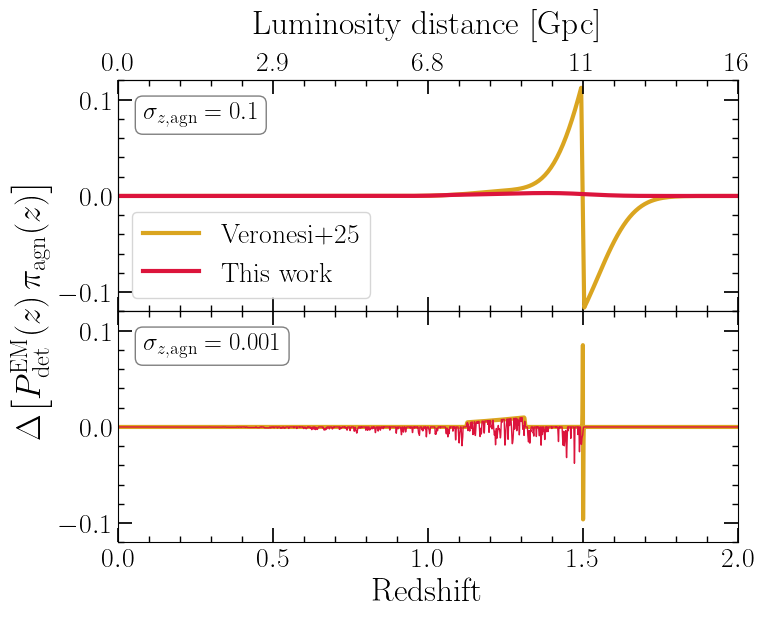

In [6]:
V25_0p001 = np.load('/home/lucas/Documents/PhD/V25_0.001.npy')
P26_0p001 = np.load('/home/lucas/Documents/PhD/P26_0.001.npy')
V25_0p1 = np.load('/home/lucas/Documents/PhD/V25_0.1.npy')
P26_0p1 = np.load('/home/lucas/Documents/PhD/P26_0.1.npy')

z_0p001 = np.linspace(0, 10, len(V25_0p001))
z_0p1 = np.linspace(0, 10, len(V25_0p1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6), gridspec_kw={'hspace': 0})
ax1.plot(z_0p1, V25_0p1, color='goldenrod', linewidth=3, label=r'Veronesi+25')
ax1.plot(z_0p1, P26_0p1, color='crimson', linewidth=3, label=r'This work')
ax2.plot(z_0p001, V25_0p001, color='goldenrod', linewidth=3, label=r'V25, $\sigma_{z, \rm agn} = 0.001$')
ax2.plot(z_0p001, P26_0p001, color='crimson', linewidth=1, label=r'P26, $\sigma_{z, \rm agn} = 0.001$')
ax1.set_xticklabels([])
ax2.set_xlabel('Redshift')
ax1.set_ylim(-0.12, 0.12)
ax2.set_ylim(-0.12, 0.12)
fig.supylabel(r'$\Delta\!\left[P^{\rm EM}_{\rm det}(z)\,\pi_{\rm agn}(z)\right]$', fontsize=25,  x=-0.01)

ax1.legend()

ax1.text(
    0.04, 0.90,
    r'$\sigma_{z,\rm agn}=0.1$',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=18,
    bbox=dict(
        facecolor='white',
        edgecolor=(0, 0, 0, 0.5),  # black with 50% opacity
        boxstyle='round,pad=0.3'
    )
)

ax2.text(
    0.04, 0.90,
    r'$\sigma_{z,\rm agn}=0.001$',
    transform=ax2.transAxes,
    ha='left',
    va='top',
    fontsize=18,
    bbox=dict(
        facecolor='white',
        edgecolor=(0, 0, 0, 0.5),  # black with 50% opacity
        boxstyle='round,pad=0.3'
    )
)

# Top axis
upperax = ax1.twiny()

upperticks = np.array([0, 0.5, 1, 1.5, 2])

upperax.set_xticks(upperticks)

upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)

ax1.set_xlim(0, 2)
ax2.set_xlim(0, 2)
upperax.set_xlim(0, 2)

plt.savefig('p26plots_v2/selfunc_error.pdf', bbox_inches='tight')

plt.show()

### 5C: Completeness vs sigma-z-AGN, colorbar sigma-fagn


### The unbiased case

In [30]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/combined_46p5_1p0.json", param_values_dict)
# sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/AAAAA_200_46p5_1p0_grid.json", param_values_dict)

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

sig_fagn2 = (
    sig_fagn[:-1:2, :-1:2] +
    sig_fagn[1::2, :-1:2] +
    sig_fagn[:-1:2, 1::2] +
    sig_fagn[1::2, 1::2]
) / 4
x2 = 0.5 * (agn_zcuts[:-1:2] + agn_zcuts[1::2])
y2 = 0.5 * (agn_zerrs[:-1:2] + agn_zerrs[1::2])
X2, Y2 = np.meshgrid(x2, y2)

In [31]:
def scale_sig(sig_have, N_have=3000, N_need=int(1e5)):
    return sig_have * np.sqrt(N_have / N_need)


[np.float64(1.9591836734693877)]


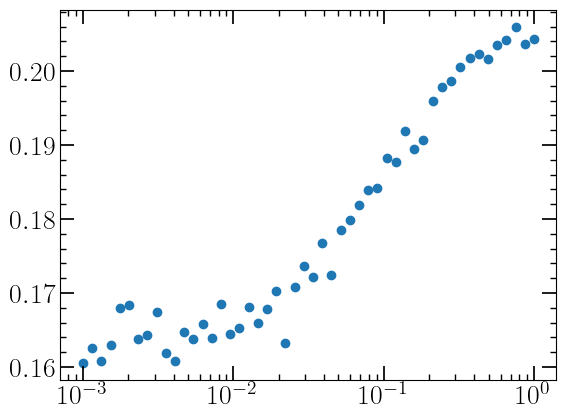

In [32]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = [np.linspace(0, 2, 50)[-2]]
print(agn_zcuts)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

s, _ = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/AAAAA_200_46p5_1p0_grid.json", param_values_dict)

plt.figure()
plt.scatter(agn_zerrs, s)
plt.semilogx()
plt.show()


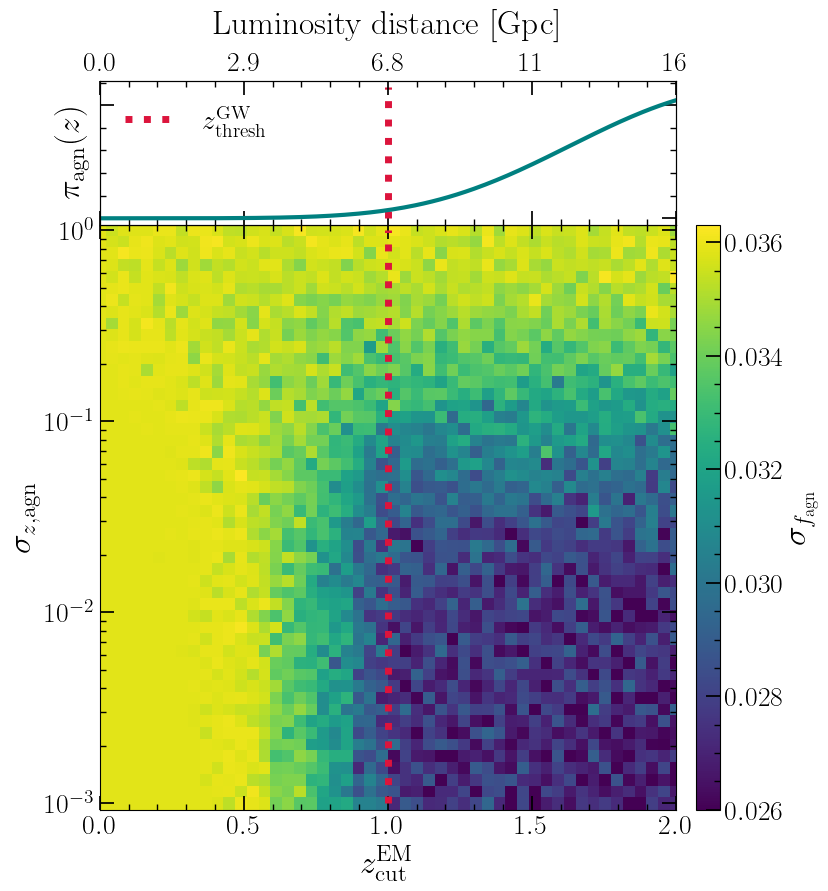

In [ ]:
import astropy.units as u

zthresh_color = 'crimson'

fig = plt.figure(figsize=(8,9))

# ---- GEOMETRY ----
left = 0.12

bottom = 0.10

main_height = 0.65
main_width  = 0.72
top_height = 0.16

ax = fig.add_axes([
    left,
    bottom,
    main_width,
    main_height
])

ax_top = fig.add_axes([
    left,
    bottom + main_height,
    main_width,
    top_height
], sharex=ax)

cax = fig.add_axes([
    left + main_width + 0.025,
    bottom,
    0.03,
    main_height
])

# sig_smooth = gaussian_filter(scale_sig(sig_fagn), sigma=2.0)

# ---- MAIN PLOT ----
pcm = ax.pcolormesh(
    X, Y, scale_sig(sig_fagn),
    shading='auto',
    cmap='viridis',
    rasterized=True,
    vmin=0.026
    # vmin=0.026, vmax=0.036
)
ax.vlines(1, 1e-3, 1, linestyle='dotted', color=zthresh_color, linewidth=5)
# ax.vlines(0.6, 1e-3, 1, linestyle='dotted', color=COLORS[0], linewidth=5)
# ax.hlines(0.03, 0, 2, linestyle='dotted', color=COLORS[0], linewidth=5)

# ---- COLOR BAR ----
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"$\sigma_{f_{\rm agn}}$")

# ---- TOP PANEL ----
z, agnpdf = np.load('/home/lucas/Documents/PhD/darksirenpop/agn_distribution/agn_redshift_pdf_46.5_kulkarni.npy')
ax_top.plot(z, agnpdf, color='teal', linewidth=3, zorder=5)

# AGN_DIST = interp1d(z, agnpdf, bounds_error=False, fill_value=0)
# Z_GRID = np.linspace(0, 10, 1024+1)
# Z_DIST_AGN = lambda z: time_dilation_correction(z) * z_cut(z, zcut=10) * AGN_DIST(z) / romb(time_dilation_correction(z) * z_cut(z, zcut=10) * AGN_DIST(z), dx=np.diff(z)[0])
# ax_top.plot(Z_GRID, Z_DIST_AGN(Z_GRID), color=COLORS[3], linewidth=3, label=r'$\pi_{\rm agn}(z) / (1 + z)$')
# ax_top.vlines(1, 0, max(np.max(agnpdf), np.max(Z_DIST_AGN(Z_GRID))), linestyle='dotted', color=COLORS[0], linewidth=5, label=r'$z_{\rm thresh}^{\rm GW}$')
ax_top.vlines(1, 0, np.max(agnpdf), linestyle='dotted', color=zthresh_color, linewidth=5, label=r'$z_{\rm thresh}^{\rm GW}$')
ax_top.legend(framealpha=0)

# Hide duplicated x tick labels
ax_top.tick_params(axis='x', labelbottom=False)

ax.set_xlabel(r"$z_{\rm cut}^{\rm EM}$")
ax.set_ylabel(r"$\sigma_{z,\rm agn}$")

ax_top.set_ylabel(r'$\pi_{\rm agn}(z)$')
ax_top.set_yticklabels([])

ax.set_yscale('log')

# Top axis
upperax = ax_top.twiny()

upperticks = np.array([0, 0.5, 1, 1.5, 2])

upperax.set_xticks(upperticks)

# upperax.set_xticklabels([
#     np.around(COSMO.luminosity_distance(z).to(u.Gpc).value, 1)
#     for z in upperticks
# ])

# upperax.set_xlabel(r'$d_L \, [\mathrm{Gpc}]$', labelpad=12, fontsize=24)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)

ax_top.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())

# plt.savefig('p26plots_v2/cat_quality_mock.pdf', bbox_inches='tight')

plt.show()


In [11]:


# # fig, ax = plt.subplots(figsize=(8,6))
# # pcm = ax.pcolormesh(
# #     X2,
# #     Y2,
# #     sig2, shading='auto', cmap='viridis', rasterized=True, vmin=0.15)


# plt.figure(figsize=(8,6))
# pcm = plt.pcolormesh(X, Y, mean_deviation, shading='auto', cmap='viridis', rasterized=True)
# # plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
# # plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
# plt.xlabel(r"$z_{\rm cut}$")
# plt.ylabel(r"$\sigma_{z, \rm agn}$")
# cbar = plt.colorbar(pcm, label=r"Deviation from truth [$\sigma_{f_{\rm agn}}$]")
# plt.yscale('log')
# # plt.legend(loc='lower left')
# # plt.savefig('./p26plots/constraint_catalog_quality.pdf')
# plt.show()


### The biased case: neglecting redshift errors

In [12]:
agn_zerrs = np.geomspace(0.001, 1, 50)
agn_zcuts = np.linspace(0, 2, 50)

param_values_dict = {
    "AGN_ZERROR": agn_zerrs,
    "AGN_ZCUT": agn_zcuts
}

# sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/AAA_final_46p5_1p0_grid_biased.json", param_values_dict)
sig_fagn, mean_deviation = sig_fagn_from_latest_runs("/home/lucas/Documents/PhD/AAAAA_200_46p5_1p0_grid_biased.json", param_values_dict)

zcut_quaia = 1.5
print(mean_err_quaia)

i = np.searchsorted(agn_zerrs, mean_err_quaia)
j = np.searchsorted(agn_zcuts, zcut_quaia)
print(agn_zerrs[i], agn_zcuts[j])
print(agn_zerrs[i-1], agn_zcuts[j-1])
print(f'Median quaia bias: {mean_deviation[i, j]:.2f} sigma')

X, Y = np.meshgrid(agn_zcuts, agn_zerrs)

# mean_deviation2 = (
#     mean_deviation[:-1:2, :-1:2] +
#     mean_deviation[1::2, :-1:2] +
#     mean_deviation[:-1:2, 1::2] +
#     mean_deviation[1::2, 1::2]
# ) / 4
# x2 = 0.5 * (agn_zcuts[:-1:2] + agn_zcuts[1::2])
# y2 = 0.5 * (agn_zerrs[:-1:2] + agn_zerrs[1::2])
# X2, Y2 = np.meshgrid(x2, y2)


0.10620452251911165
0.1206792640639329 1.510204081632653
0.10481131341546852 1.4693877551020407
Median quaia bias: -0.76 sigma


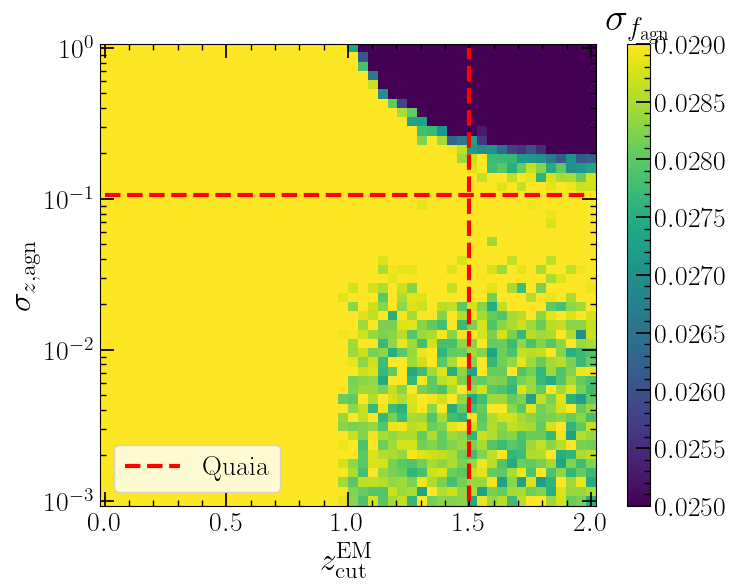

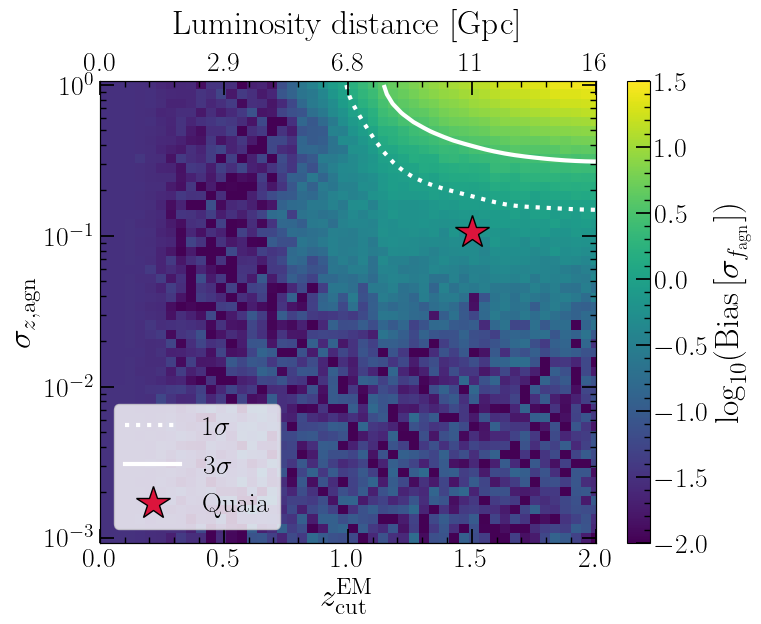

In [13]:
plt.figure(figsize=(8,6))
pcm = plt.pcolormesh(X, Y, scale_sig(sig_fagn), shading='auto', cmap='viridis', rasterized=True, vmin=0.025, vmax=0.029)
plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors='red', linewidth=3, label='Quaia')
plt.vlines(zcut_quaia, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors='red', linewidth=3)
plt.xlabel(r"$z_{\rm cut}^{\rm EM}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm)
cbar.ax.set_title(r"$\sigma_{f_{\rm agn}}$")
plt.yscale('log')
plt.legend(loc='lower left')
# plt.savefig('./p26plots/constraint_catalog_quality_biased.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8,6))

# fig, ax = plt.subplots(figsize=(8,6))
# m2 = np.log10(abs(mean_deviation2))
# pcm = ax.pcolormesh(
#     X2,
#     Y2,
#     m2, shading='auto', cmap='viridis', rasterized=True)

conts = [np.log10(1), np.log10(3)]
m = np.log10(abs(mean_deviation))

m_smooth = gaussian_filter(m, sigma=2.0)
pcm = plt.pcolormesh(X, Y, m, shading='auto', cmap='viridis', rasterized=True, vmin=-2, vmax=1.5)
cs = plt.contour(X, Y, m_smooth, levels=conts, colors='white', linewidths=3, linestyles=['dotted', 'solid'])
# plt.hlines(mean_err_quaia, agn_zcuts.min(), agn_zcuts.max(), linestyles='dashed', colors=COLORS[6], linewidth=3, label='Quaia')
# plt.vlines(1.5, agn_zerrs.min(), agn_zerrs.max(), linestyles='dashed', colors=COLORS[6], linewidth=3)
plt.plot(1.5, mean_err_quaia, color=COLORS[6], linewidth=3, linestyle=' ', marker='*', markeredgecolor='black', markersize=25, label='Quaia')
plt.xlabel(r"$z^{\rm EM}_{\rm cut}$")
plt.ylabel(r"$\sigma_{z, \rm agn}$")
cbar = plt.colorbar(pcm, label=r"$\log_{10}(\mathrm{Bias} \, [\sigma_{f_{\rm agn}}])$")
plt.yscale('log')

# Top axis
upperax = ax.twiny()

upperticks = np.array([0, 0.5, 1, 1.5, 2])

upperax.set_xticks(upperticks)

# upperax.set_xticklabels([
#     np.around(COSMO.luminosity_distance(z).to(u.Gpc).value, 1)
#     for z in upperticks
# ])

# upperax.set_xlabel(r'$d_L \, [\mathrm{Gpc}]$', labelpad=12, fontsize=24)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)

ax.set_xlim(X.min(), X.max())
upperax.set_xlim(X.min(), X.max())

plt.legend(loc='lower left', 
           handles=[mlines.Line2D([], [], color='white', linewidth=3, label=r"$1\sigma$", linestyle='dotted'),
                    mlines.Line2D([], [], color='white', linewidth=3, label=r"$3\sigma$"),
                    mlines.Line2D([], [], color=COLORS[6], linewidth=3, linestyle=' ', marker='*', markeredgecolor='black', markersize=25, label='Quaia')])
# plt.savefig('p26plots_v2/bias_agn_zerror.pdf', bbox_inches='tight')
plt.show()



In [14]:
def get_avg_alpha_coeffs(mockdata_root, start=0, stop=1000, Ntot=int(1e5)):

    avg_alpha_A = []
    avg_alpha_B = []

    Ngw_A_tot = 0
    Ngw_B_tot = 0

    Na = 0
    Nb = 0
    for i in np.arange(200)[start:stop]:

        g = glob.glob(f'{mockdata_root}/output_run_{i+1}_*')
        
        if len(g) == 0:
            Ngw_A = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/agn/*'))
            Ngw_B = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/alt/*'))
            ftemp = 0.5
        
        else:
            Ngw_A = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*'))
            Ngw_B = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/alt/*'))
            ftemp = float(g[0].split('_')[-1])

        Ngw_A_tot += Ngw_A
        Ngw_B_tot += Ngw_B
        Na += ftemp * Ntot
        Nb += (1 - ftemp) * Ntot

        avg_alpha_A.append(Ngw_A / (ftemp * Ntot))
        avg_alpha_B.append(Ngw_B / ((1 - ftemp) * Ntot))

    print('from Ngw', Ngw_A_tot / Na, Ngw_B_tot / Nb)
    print('from alpha', np.mean(np.array(avg_alpha_A)), np.mean(np.array(avg_alpha_B)))
    print('median from alpha', np.median(np.array(avg_alpha_A)), np.median(np.array(avg_alpha_B)))

    return np.mean(np.array(avg_alpha_A)), np.mean(np.array(avg_alpha_B))

print(get_avg_alpha_coeffs('/home/lucas/Documents/PhD/mock_gws_nonuniform_True_zmax_10_zcut_1_LVKvols', Ntot=int(3e3)))
print(get_avg_alpha_coeffs('/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_100000_zmax_10_zcut_0.3_LVKvols'))


# remove = []
# for i in range(200):
#     Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*'))
#     if Ngw == 0:
#         remove.append(i)
#         print(i)

# mask = np.zeros(200, dtype=bool)
# mask[remove] = True
def filter_posteriors(posteriors, start, stop):
    posteriors = posteriors[:, np.isfinite(posteriors).all(axis=0)]
    posteriors = posteriors[:, start:stop]
    posteriors_shape = posteriors.shape
    return posteriors, posteriors_shape


# def correct_posteriors(posterior, posteriors_shape, mockdata_root, log_alpha):
#     corrected_posteriors = np.zeros(posteriors_shape)
#     Ngw_arr = []
#     for k, (i, post) in enumerate( zip(np.arange(200)[start:stop], posterior.T) ):

#         g = glob.glob(f'{mockdata_root}/output_run_{i+1}_*')
#         if len(g) == 0:
#             Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/agn/*')) + len(glob.glob(f'{mockdata_root}/output_run_{i+1}/skymaps/alt/*'))
#         else:
#             Ngw = len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/agn/*')) + len(glob.glob(f'{mockdata_root}/output_run_{i+1}_*/skymaps/alt/*'))
        
#         corrected_log_llh = post - Ngw * log_alpha
#         corrected_posteriors[:, k] = corrected_log_llh
#         Ngw_arr.append(Ngw)
#     return corrected_posteriors, Ngw_arr


def get_inverse_cdf_evals(nx, posterior, true_fagns):
    cdfs = get_cdfs(posterior)

    cdf_at_true_val = np.zeros(nx)
    q005 = np.zeros(nx)
    q050 = np.zeros(nx)
    q095 = np.zeros(nx)
    q016 = np.zeros(nx)
    q084 = np.zeros(nx)
    for i, cdf in enumerate(cdfs.T):
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q005[i] = inverse_cdf(0.05)
        q050[i] = inverse_cdf(0.50)
        q095[i] = inverse_cdf(0.95)
        q016[i] = inverse_cdf(0.16)
        q084[i] = inverse_cdf(0.84)

        cdf_at_true_val[i] = interp1d(LOG_LLH_X_AX, cdf)(true_fagns[i])
    return cdf_at_true_val, q005, q016, q050, q084, q095


from Ngw 0.0 0.0
from alpha 0.0 0.0
median from alpha 0.0 0.0
(np.float64(0.0), np.float64(0.0))
from Ngw 4.054217195741797e-05 0.0030445813528969935
from alpha 3.810575704866497e-05 0.003033229772457515
median from alpha 3.299076261025372e-05 0.0030400874580030586
(np.float64(3.810575704866497e-05), np.float64(0.003033229772457515))


In [15]:
# MC estimate of alpha

# agn_efficiency, alt_efficiency = 4.39e-05, 0.003033  # 46.5, z=0.3
# agn_efficiency, alt_efficiency = 0.0143458, 0.0990136  # 46.5, z=1

# agn_efficiency, alt_efficiency = 0.001407431397715323, 0.003029223806417793  # 44.5, z=0.3
# agn_efficiency, alt_efficiency = 0.08676494696142759, 0.09875389657421599  # 44.5, z=1

# Analytical estimate of alpha
# agn_efficiency, alt_efficiency = 4.158609789980338e-05, 0.0029181111806662182  # 46.5, z=0.3
# agn_efficiency, alt_efficiency = 0.013998555438527785, 0.09782308039965569  # 46.5, z=1

# agn_efficiency, alt_efficiency = 0.0014369976475854384, 0.0029180323456043876  # 44.5, z=0.3
# agn_efficiency, alt_efficiency = 0.08591413903042647, 0.09786327907001525  # 44.5, z=1


In [16]:
# '/home/lucas/Documents/PhD/fagn_posteriors/p26_post_realdata_False_2026-05-06T15:48:57.887421.npz'  # 44.5, z=0.3, no catalogue

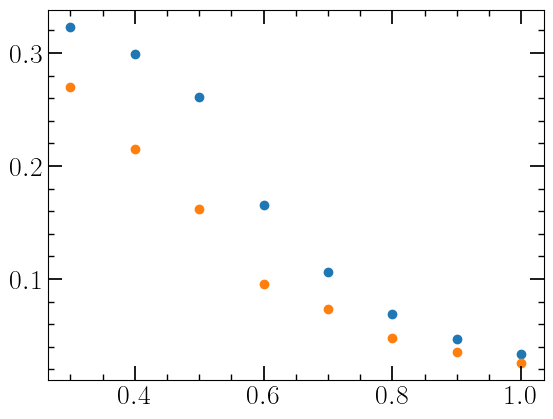

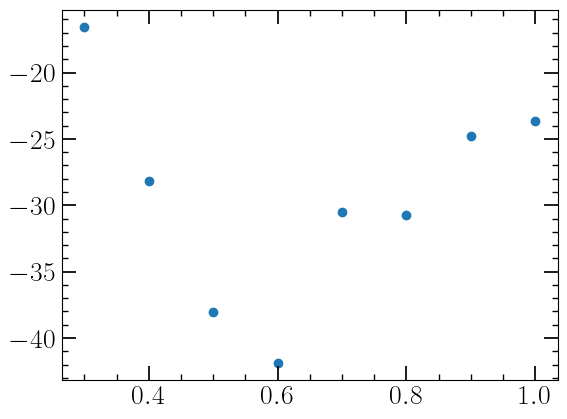

[-16.55204857 -28.19917114 -38.02904633 -41.86535155 -30.51956824
 -30.70013996 -24.77583804 -23.66890076] -29.288758072624468 7.528532781465787


In [17]:
worst = np.array([0.3231833849266671, 0.29911456841228345, 0.26067878910253717, 0.16504789151441188, 0.10625309088391974, 0.06864124530899747, 0.04716787370986533, 0.033946049612580464])
best = np.array([0.26968991407519344, 0.2147667393689137, 0.161545131633744, 0.09595001150828113, 0.07382510630537996, 0.04756828692942566, 0.03548163771245005, 0.02591139281844562])
x = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

plt.figure()
plt.scatter(x, worst)
plt.scatter(x, best)
plt.show()

plt.figure()
plt.scatter(x, (best - worst) / worst * 100)
plt.show()

print((best - worst) / worst * 100, np.mean((best - worst) / worst * 100), np.std((best - worst) / worst * 100))

0.033946049612580464
0.3231833849266671
0.26968991407519344
0.02591139281844562
0.10625309088391974
0.07382510630537996
0.16504789151441188
0.09595001150828113
0.04716787370986533
0.03548163771245005
0.06864124530899747
0.04756828692942566
0.26067878910253717
0.161545131633744
0.29911456841228345
0.2147667393689137


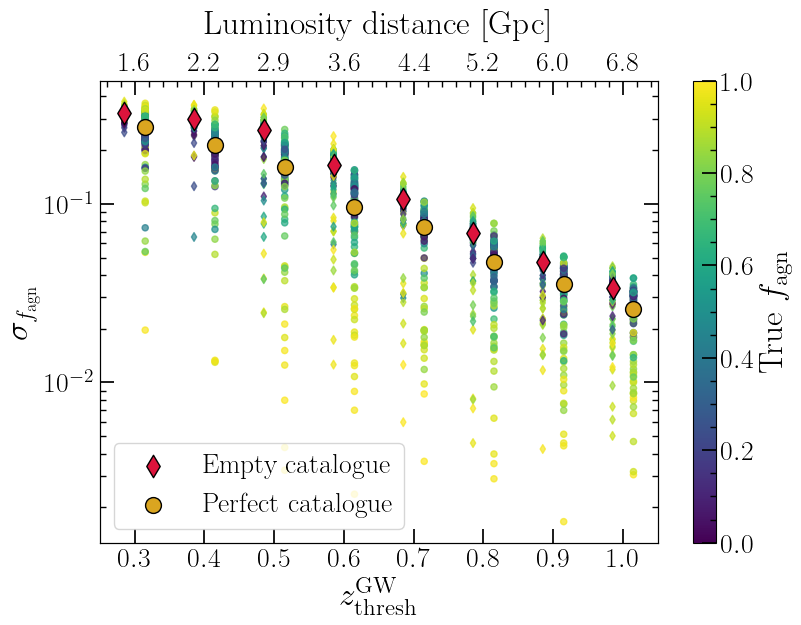

In [18]:
# narr = np.array([100, 1000, 10000, 100000])
# sigarr = np.array([0.12374656546819078, 0.04339511689740713, 0.0139280046121739, 0.0043379842409952685])

# nn = np.linspace(100, 100000, 1000)
# model = sigarr[1] * np.sqrt(narr[1]) / np.sqrt(nn)

def scale_sig(sig_have, N_have=3000, N_need=int(1e5)):
    return sig_have * np.sqrt(N_have / N_need)

ppath_1p0_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:01:32.995834.npz'
ppath_0p3_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:00:05.335445.npz' 
ppath_0p3_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T13:23:17.190061.npz'
ppath_1p0_best = "./fagn_posteriors/p26_post_realdata_False_2026-06-01T14:22:05.703371.npz" 
ppath_0p7_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T13:56:50.071755.npz' 
ppath_0p7_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:13:07.208748.npz'
ppath_0p6_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:31:26.596947.npz' 
ppath_0p6_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:49:39.424950.npz'
ppath_0p9_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:55:47.568877.npz' 
ppath_0p9_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:59:15.731813.npz'
ppath_0p8_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T18:04:11.351191.npz' 
ppath_0p8_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T18:10:16.617420.npz'
ppath_0p5_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-02T12:35:35.144718.npz' 
ppath_0p5_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T12:38:28.160445.npz'
ppath_0p4_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-02T14:24:08.136028.npz' 
ppath_0p4_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T12:55:24.817817.npz'

plt.figure(figsize=(9,6))

bestcasemarker = 'o'
worstcasemarker = 'd'
worstcasecolor = 'crimson'
bestcasecolor = 'goldenrod'
markersize = 130
dx = 0.015

for i, (marker, color, zthresh, N, ppath) in enumerate( zip(
                                 np.array([worstcasemarker, worstcasemarker, bestcasemarker, 
                                           bestcasemarker, worstcasemarker, bestcasemarker,
                                           worstcasemarker, bestcasemarker, worstcasemarker,
                                           bestcasemarker, worstcasemarker, bestcasemarker,
                                           worstcasemarker, bestcasemarker, worstcasemarker,
                                           bestcasemarker]),
                                 np.array([worstcasecolor, worstcasecolor, bestcasecolor, 
                                           bestcasecolor, worstcasecolor, bestcasecolor,
                                           worstcasecolor, bestcasecolor, worstcasecolor,
                                           bestcasecolor, worstcasecolor, bestcasecolor,
                                           worstcasecolor, bestcasecolor,worstcasecolor, 
                                           bestcasecolor]),
                                 np.array([1.0 - dx, 0.3 - dx, 0.3 + dx, 
                                           1.0 + dx, 0.7 - dx, 0.7 + dx,
                                           0.6 - dx, 0.6 + dx, 0.9 - dx,
                                           0.9 + dx, 0.8 - dx, 0.8 + dx,
                                           0.5 - dx, 0.5 + dx, 0.4 - dx,
                                           0.4 + dx]), 
                                 np.array([3e3, 1e5, 1e5, 
                                           3e3, 2e4, 2e4,
                                           5e4, 5e4, 5e3, 
                                           5e3, 1e4, 1e4,
                                           1e5, 1e5, 1e5,
                                           1e5]),
                                 np.array([ppath_1p0_worst, ppath_0p3_worst, ppath_0p3_best, 
                                           ppath_1p0_best, ppath_0p7_worst, ppath_0p7_best,
                                           ppath_0p6_worst, ppath_0p6_best, ppath_0p9_worst,
                                           ppath_0p9_best, ppath_0p8_worst, ppath_0p8_best,
                                           ppath_0p5_worst, ppath_0p5_best, ppath_0p4_worst,
                                           ppath_0p4_best])) ):
    # if i < 4:
    #     continue

    start = 0
    stop = 200

    posterior, posteriors_shape, true_fagns = load_log_llh(ppath, fagn_true=None)
    true_fagns = true_fagns[start:stop]
    posterior, posteriors_shape = filter_posteriors(posterior, start, stop)
    pdfs = get_pdfs(posterior, LOG_LLH_X_AX)
    cdf_at_true_val, q005, q016, q050, q084, q095 = get_inverse_cdf_evals(posteriors_shape[1], posterior, true_fagns)

    sig = (q084 - q016)/2

    sig_plot = scale_sig(sig, N_have=N)

    # plt.scatter(true_fagns, sig_plot, c=q050)
    # plt.xlabel('True fagn')
    # plt.ylabel('Sigma of posterior')
    # plt.colorbar(label='Median of posterior')
    # plt.show()

    sig_median = np.median(sig_plot)
    sig_upper = np.quantile(sig_plot, 0.84) - sig_median
    sig_lower = sig_median - np.quantile(sig_plot, 0.16)

    plt.scatter(np.tile(zthresh, len(q050)), sig_plot, c=true_fagns, alpha=0.7, s=20, vmin=0, vmax=1, marker=marker)
    
    plt.scatter(zthresh, sig_median, color=color, zorder=10, marker=marker, s=markersize, edgecolor='black')
    print(sig_median)
    # plt.errorbar(zthresh, sig_median, linestyle='', yerr=[[sig_lower], [sig_upper]], color=color, zorder=10, marker=marker, capsize=3)
plt.colorbar(label=r'True $f_{\rm agn}$')
# h1 = plt.errorbar(
#     [], [], yerr=[[1], [1]],
#     linestyle='',
#     color=worstcasecolor,
#     marker=worstcasemarker,
#     capsize=3,
#     label='No catalogue'
# )

# h2 = plt.errorbar(
#     [], [], yerr=[[1], [1]],
#     linestyle='',
#     color=bestcasecolor,
#     marker=bestcasemarker,
#     capsize=3,
#     label='Perfect catalogue'
# )

h1 = plt.scatter(
    [], [],
    color=worstcasecolor,
    marker=worstcasemarker,
    s=markersize,
    edgecolor='black',
    label='Empty catalogue'
)

h2 = plt.scatter(
    [], [],
    color=bestcasecolor,
    marker=bestcasemarker,
    s=markersize,
    edgecolor='black',
    label='Perfect catalogue'
)

plt.legend(handles=[h1, h2])
plt.xlabel(r'$z^{\rm GW}_{\rm thresh}$')
plt.ylabel(r'$\sigma_{f_{\rm agn}}$')
plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlim(0.25, 1.05)
ax = plt.gca()
ax.xaxis.set_minor_locator(plt.NullLocator())

# Top axis
upperax = ax.twiny()

upperticks = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

upperax.set_xticks(upperticks)

# upperax.set_xticklabels([
#     np.around(COSMO.luminosity_distance(z).to(u.Gpc).value, 1)
#     for z in upperticks
# ])

# upperax.set_xlabel(r'$d_L \, [\mathrm{Gpc}]$', labelpad=12, fontsize=24)
upperax.set_xticklabels([sigfig_str(v, 2) for v in COSMO.luminosity_distance(upperticks).to(u.Gpc).value])
upperax.set_xlabel(r'Luminosity distance $[\mathrm{Gpc}]$', labelpad=12, fontsize=24)

ax.set_xlim(0.25, 1.05)
upperax.set_xlim(0.25, 1.05)

plt.savefig('p26plots_v2/limits_mock.pdf', bbox_inches='tight')
plt.semilogy()
plt.savefig('p26plots_v2/limits_mock_logy.pdf', bbox_inches='tight')
plt.show()


In [19]:
# # narr = np.array([100, 1000, 10000, 100000])
# # sigarr = np.array([0.12374656546819078, 0.04339511689740713, 0.0139280046121739, 0.0043379842409952685])

# # nn = np.linspace(100, 100000, 1000)
# # model = sigarr[1] * np.sqrt(narr[1]) / np.sqrt(nn)

# def scale_sig(sig_have, N_have=3000, N_need=int(1e5)):
#     return sig_have * np.sqrt(N_have / N_need)

# ppath_1p0_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:01:32.995834.npz'
# ppath_0p3_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:00:05.335445.npz' 
# ppath_0p3_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T13:23:17.190061.npz'
# ppath_1p0_best = "./fagn_posteriors/p26_post_realdata_False_2026-06-01T14:22:05.703371.npz" 
# ppath_0p7_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T13:56:50.071755.npz' 
# ppath_0p7_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T14:13:07.208748.npz'
# ppath_0p6_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:31:26.596947.npz' 
# ppath_0p6_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:49:39.424950.npz'
# ppath_0p9_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:55:47.568877.npz' 
# ppath_0p9_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T17:59:15.731813.npz'
# ppath_0p8_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-01T18:04:11.351191.npz' 
# ppath_0p8_best = './fagn_posteriors/p26_post_realdata_False_2026-06-01T18:10:16.617420.npz'
# ppath_0p5_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-02T12:35:35.144718.npz' 
# ppath_0p5_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T12:38:28.160445.npz'
# ppath_0p4_worst = './fagn_posteriors/p26_post_realdata_False_2026-06-02T14:24:08.136028.npz' 
# ppath_0p4_best = './fagn_posteriors/p26_post_realdata_False_2026-06-03T12:55:24.817817.npz'

# plt.figure(figsize=(9,6))

# bestcasemarker = 'o'
# worstcasemarker = 'd'
# worstcasecolor = 'crimson'
# bestcasecolor = 'goldenrod'
# markersize = 130
# dx = 0.015

# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# all_z = []
# all_sig = []
# all_fagn = []
# all_markers = []

# for i, (marker, color, zthresh, N, ppath) in enumerate( zip(
#                                  np.array([worstcasemarker, worstcasemarker, bestcasemarker, 
#                                            bestcasemarker, worstcasemarker, bestcasemarker,
#                                            worstcasemarker, bestcasemarker, worstcasemarker,
#                                            bestcasemarker, worstcasemarker, bestcasemarker,
#                                            worstcasemarker, bestcasemarker, worstcasemarker,
#                                            bestcasemarker]),
#                                  np.array([worstcasecolor, worstcasecolor, bestcasecolor, 
#                                            bestcasecolor, worstcasecolor, bestcasecolor,
#                                            worstcasecolor, bestcasecolor, worstcasecolor,
#                                            bestcasecolor, worstcasecolor, bestcasecolor,
#                                            worstcasecolor, bestcasecolor,worstcasecolor, 
#                                            bestcasecolor]),
#                                  np.array([1.0 - dx, 0.3 - dx, 0.3 + dx, 
#                                            1.0 + dx, 0.7 - dx, 0.7 + dx,
#                                            0.6 - dx, 0.6 + dx, 0.9 - dx,
#                                            0.9 + dx, 0.8 - dx, 0.8 + dx,
#                                            0.5 - dx, 0.5 + dx, 0.4 - dx,
#                                            0.4 + dx]), 
#                                  np.array([3e3, 1e5, 1e5, 
#                                            3e3, 2e4, 2e4,
#                                            5e4, 5e4, 5e3, 
#                                            5e3, 1e4, 1e4,
#                                            1e5, 1e5, 1e5,
#                                            1e5]),
#                                  np.array([ppath_1p0_worst, ppath_0p3_worst, ppath_0p3_best, 
#                                            ppath_1p0_best, ppath_0p7_worst, ppath_0p7_best,
#                                            ppath_0p6_worst, ppath_0p6_best, ppath_0p9_worst,
#                                            ppath_0p9_best, ppath_0p8_worst, ppath_0p8_best,
#                                            ppath_0p5_worst, ppath_0p5_best, ppath_0p4_worst,
#                                            ppath_0p4_best])) ):
#     # if i < 4:
#     #     continue

#     start = 0
#     stop = 200

#     posterior, posteriors_shape, true_fagns = load_log_llh(ppath, fagn_true=None)
#     true_fagns = true_fagns[start:stop]
#     posterior, posteriors_shape = filter_posteriors(posterior, start, stop)
#     pdfs = get_pdfs(posterior, LOG_LLH_X_AX)
#     cdf_at_true_val, q005, q016, q050, q084, q095 = get_inverse_cdf_evals(posteriors_shape[1], posterior, true_fagns)

#     sig = (q084 - q016)/2

#     sig_plot = scale_sig(sig, N_have=N)

#     all_z.extend(np.tile(zthresh, len(sig_plot)))
#     all_sig.extend(sig_plot)
#     all_fagn.extend(true_fagns)
#     all_markers.extend([marker] * len(sig_plot))

#     # plt.scatter(true_fagns, sig_plot, c=q050)
#     # plt.xlabel('True fagn')
#     # plt.ylabel('Sigma of posterior')
#     # plt.colorbar(label='Median of posterior')
#     # plt.show()

#     sig_median = np.median(sig_plot)
#     sig_upper = np.quantile(sig_plot, 0.84) - sig_median
#     sig_lower = sig_median - np.quantile(sig_plot, 0.16)

#     plt.scatter(np.tile(zthresh, len(q050)), sig_plot, c=true_fagns, alpha=0.7, s=20, vmin=0, vmax=1, marker=marker)
    
#     plt.scatter(zthresh, sig_median, color=color, zorder=10, marker=marker, s=markersize, edgecolor='black')
#     # plt.errorbar(zthresh, sig_median, linestyle='', yerr=[[sig_lower], [sig_upper]], color=color, zorder=10, marker=marker, capsize=3)
# plt.colorbar(label=r'True $f_{\rm agn}$')
# # h1 = plt.errorbar(
# #     [], [], yerr=[[1], [1]],
# #     linestyle='',
# #     color=worstcasecolor,
# #     marker=worstcasemarker,
# #     capsize=3,
# #     label='No catalogue'
# # )

# # h2 = plt.errorbar(
# #     [], [], yerr=[[1], [1]],
# #     linestyle='',
# #     color=bestcasecolor,
# #     marker=bestcasemarker,
# #     capsize=3,
# #     label='Perfect catalogue'
# # )

# h1 = plt.scatter(
#     [], [],
#     color=worstcasecolor,
#     marker=worstcasemarker,
#     s=markersize,
#     edgecolor='black',
#     label='Empty catalogue'
# )

# h2 = plt.scatter(
#     [], [],
#     color=bestcasecolor,
#     marker=bestcasemarker,
#     s=markersize,
#     edgecolor='black',
#     label='Perfect catalogue'
# )

# plt.legend(handles=[h1, h2])
# plt.xlabel(r'$z^{\rm GW}_{\rm thresh}$')
# plt.ylabel(r'$\sigma_{f_{\rm agn}}$')
# plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
# plt.xlim(0.25, 1.05)
# ax = plt.gca()
# ax.xaxis.set_minor_locator(plt.NullLocator())

# # Top axis
# upperax = ax.twiny()

# upperticks = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# upperax.set_xticks(upperticks)

# upperax.set_xticklabels([
#     np.around(COSMO.luminosity_distance(z).to(u.Gpc).value, 1)
#     for z in upperticks
# ])

# upperax.set_xlabel(r'$d_L \, [\mathrm{Gpc}]$', labelpad=12, fontsize=24)

# ax.set_xlim(0.25, 1.05)
# upperax.set_xlim(0.25, 1.05)




# # -------------------------
# # Inset zoom (0.7 <= z <= 1.0)
# # -------------------------

# axins = inset_axes(
#     ax,
#     width="42%",
#     height="42%",
#     loc="upper right",
#     borderpad=1.5,
# )

# all_z = np.asarray(all_z)
# all_sig = np.asarray(all_sig)
# all_fagn = np.asarray(all_fagn)
# all_markers = np.asarray(all_markers)

# mask = all_z >= 0.7 - dx - 1e-6

# for marker in np.unique(all_markers):
#     m = mask & (all_markers == marker)

#     axins.scatter(
#         all_z[m],
#         all_sig[m],
#         c=all_fagn[m],
#         alpha=0.7,
#         s=20,
#         vmin=0,
#         vmax=1,
#         marker=marker,
#     )

# axins.set_xlim(0.68, 1.02)

# # automatic y limits
# y = all_sig[mask]
# pad = 0.05 * (y.max() - y.min())
# axins.set_ylim(y.min() - pad, y.max() + pad)

# axins.set_xticks([0.7, 0.8, 0.9, 1.0])
# axins.tick_params(labelsize=9)

# # draw rectangle and connectors
# mark_inset(ax, axins, loc1=2, loc2=4,
#            fc="none", ec="0.5", lw=1)

# # plt.savefig('p26plots_v2/limits_mock.pdf', bbox_inches='tight')
# # plt.semilogy()
# # plt.savefig('p26plots_v2/limits_mock_logy.pdf', bbox_inches='tight')
# plt.show()


In [20]:
'''
The errorbars solely show the fluctuations due to ESTIMATED f_agn, NOT TRUE f_agn. Due to very slight errors alpha, upward outliers become more common and stretch the errorbars downwards,
because the ESTIMATED f_agn goes to 1 due to overestimation, where the constraints are better. I am not sure we want to show that.
'''

'\nThe errorbars solely show the fluctuations due to ESTIMATED f_agn, NOT TRUE f_agn. Due to very slight errors alpha, upward outliers become more common and stretch the errorbars downwards,\nbecause the ESTIMATED f_agn goes to 1 due to overestimation, where the constraints are better. I am not sure we want to show that.\n'

In [21]:
# alphs = []
# alph_dict = {}
# alphs_agn = []
# alph_dict_agn = {}
# for path in glob.glob('/home/lucas/Documents/PhD/mock_gws_agndist_46.5_ngw_20000_zmax_10_zcut_0.7_LVKvols/output_run_*'):
#     id = path.split('_')[-3] 

#     agn_det = f'{path}/true_gw_coords/agn/true_r_theta_phi.txt'
#     agn_nondet = f'{path}/true_gw_coords_nondetections/agn/true_r_theta_phi.txt'

#     Ndet = np.genfromtxt(agn_det).shape[0]
#     Nnondet = np.genfromtxt(agn_nondet).shape[0]
#     Ntot = Ndet + Nnondet

#     alpha_agn = Ndet / Ntot
#     alphs_agn.append(alpha_agn)
#     alph_dict_agn[id] = alpha_agn

#     alt_det = f'{path}/true_gw_coords/alt/true_r_theta_phi.txt'
#     alt_nondet = f'{path}/true_gw_coords_nondetections/alt/true_r_theta_phi.txt'

#     Ndet = np.genfromtxt(alt_det).shape[0]
#     Nnondet = np.genfromtxt(alt_nondet).shape[0]
#     Ntot = Ndet + Nnondet

#     alpha_alt = Ndet / Ntot
#     alphs.append(alpha_alt)
#     alph_dict[id] = alpha_alt / alpha_agn
# alphs = np.array(alphs)
# alphs_agn = np.array(alphs_agn)
# # print(repr(alphs))
# # print(repr(alphs_agn))
# # print(alphs / alphs_agn)
# print('ratios:', alph_dict)

# print(np.mean(alphs), np.mean(alphs_agn))
# print(np.median(alphs), np.median(alphs_agn))


Median 90% CI size = 0.8321090199825241
Median 1 sigma = 0.30846095392187817
Mean 1 sigma = 0.3052700918666576



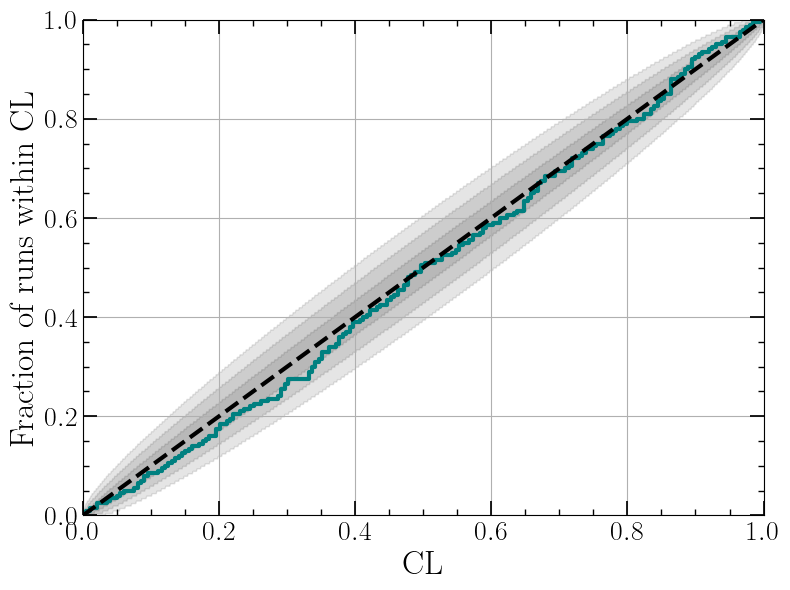

In [ ]:
PLOT_OR_ERRORBAR = 'errorbar'

# FINALFINAL QUAIA ZTHR = 1.0  ['./fagn_posteriors/p26_post_realdata_False_2026-06-03T13:28:26.762692.npz']
# FINALFINAL QUAIA ZTHR = 0.3  ['./fagn_posteriors/p26_post_realdata_False_2026-06-03T11:48:52.256318.npz']

# NEW 0.3 QUAIA: 
posterior_paths = ['./fagn_posteriors/p26_post_realdata_False_2026-06-03T11:48:52.256318.npz']

# with open('/home/lucas/Documents/PhD/AAAAA_200_46p5_1p0_grid.json', "r") as f:
#     runs = json.load(f)
#     posterior_paths = [r["filename"] for r in runs]

# labels = [r'$z_{\rm thresh}^{\rm GW} = 0.3$', r'$z_{\rm thresh}^{\rm GW} = 0.4$', r'$z_{\rm thresh}^{\rm GW} = 0.5$']
start = 0
stop = 200
fagn_true = None

fig1, ax2 = plt.subplots(figsize=(8,6))
for k, posterior_path in enumerate(posterior_paths):

    posterior, posteriors_shape, true_fagns = load_log_llh(posterior_path, fagn_true=fagn_true)
    true_fagns = true_fagns[start:stop]
    posterior, posteriors_shape = filter_posteriors(posterior, start, stop)

    pdfs = get_pdfs(posterior, LOG_LLH_X_AX)

    cdf_at_true_val, q005, q016, q050, q084, q095 = get_inverse_cdf_evals(posteriors_shape[1], posterior, true_fagns)
    print(f'Median 90% CI size = {np.median(q095[~np.isnan(q095)] - q005[~np.isnan(q095)])}')
    print(f'Median 1 sigma = {np.median( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}')
    print(f'Mean 1 sigma = {np.mean( q084[~np.isnan(q084)] - q016[~np.isnan(q016)] ) / 2}\n')

    sig = (q084 - q016)/2


    ########## Plotting ##########

    idx = k

    # fig, ax = plt.subplots(figsize=(8,6))
    # ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[0], alpha=0.3)
    # ax.hlines(1, 0, 1, linestyles='dashed', colors='black', linewidth=3, label='Prior')
    # ax.set_xlabel(r'$f_{\rm agn}$')
    # ax.set_ylabel(r'Probability density')
    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, min(1.1 * np.max(pdfs), 5))
    # ax.legend()
    # plt.show()

    
    # xx = np.arange(posteriors_shape[1])
    # # Posteriors
    # if PLOT_OR_ERRORBAR == 'plot':
    #     ax1.plot(xx, q050, color='orangered', linewidth=3, label='Median')
    #     ax1.fill_between(xx, q005, q095, color='orangered', alpha=0.3, label=r'90$\%$ CI')
    # elif PLOT_OR_ERRORBAR == 'errorbar':
    #     ax1.errorbar(x=xx, 
    #                 y=q050,
    #                 yerr=np.array([q050 - q005, q095 - q050]),
    #                 linestyle='',
    #                 marker='.',
    #                 color='red',
    #                 capsize=2,
    #                 elinewidth=1)
    #     ax1.errorbar(x=xx[abs(q050 - true_fagns)/(q084 - q016) > 5], 
    #                 y=q050[abs(q050 - true_fagns)/(q084 - q016) > 5],
    #                 linestyle='',
    #                 marker='.',
    #                 color='blue',
    #                 capsize=2,
    #                 elinewidth=1)
    #     print('5sigma off:', xx[abs(q050 - true_fagns)/(q084 - q016) > 5])
    # ax1.scatter(xx, true_fagns, color='black', marker='.')
    # ax1.set_xlabel(r'Realization Number')
    # ax1.set_ylabel(r'$f_{\rm agn, estim}$')
    # ax1.grid()
    # ax1.set_xlim(0, posteriors_shape[1] - 1)
    # ax1.set_ylim(0, 1)

    # PP plot
    Nrep = len(cdf_at_true_val)
    comparisons = np.linspace(0, 1, Nrep)
    pp_plot = np.zeros(Nrep)
    for i in range(len(pp_plot)):
        pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
    pp_plot /= len(cdf_at_true_val)

    ax2.step(comparisons, pp_plot, linewidth=3, color='teal')  # COLORS[idx], label=labels[k]

CI = np.linspace(0, 0.9999, 1000)
for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.1,0.1]):
    edge_of_bound = (1. - ci) / 2.
    lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
    upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
    lower[0] = 0
    upper[0] = 0
    plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid()
# ax2.set_title(str(Nrep) + ' realizations of ' + r'$f_{\rm agn, true} =$ ' + str(fagn_true))
ax2.set_xlabel('CL')
ax2.set_ylabel('Fraction of runs within CL')
# ax2.legend()
plt.tight_layout()
# plt.savefig(f'p26plots_v2/ppplot_0p3.pdf', bbox_inches='tight')
plt.show()

# fig, ax = plt.subplots(figsize=(8,6))
# s016, s084, s050 = np.quantile(sig, 0.16), np.quantile(sig, 0.84), np.quantile(sig, 0.5)
# ax.hlines(s050, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='solid', colors='red', linewidth=3, label='Median sigma')
# ax.hlines(s084, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='dashed', colors='red', linewidth=3)
# ax.hlines(s016, np.min(Ngw_arr), np.max(Ngw_arr), linestyles='dashed', colors='red', linewidth=3)
# ax.scatter(Ngw_arr, sig, c=true_fagns)
# NN = np.linspace(np.min(Ngw_arr), np.max(Ngw_arr), len(Ngw_arr))
# ax.plot(NN, sig[np.argmin(Ngw_arr)] / np.sqrt(NN / np.min(Ngw_arr)))
# plt.show()

